[*********************100%***********************]  3 of 3 completed


=== Portefeuille optimal (scipy) ===
Poids : [0.324 0.676 0.   ]
Rendement : 31.58% | Risque : 26.95% | Sharpe : 1.06
Rendement : 31.62% | Risque : 27.07% | Sharpe : 1.06


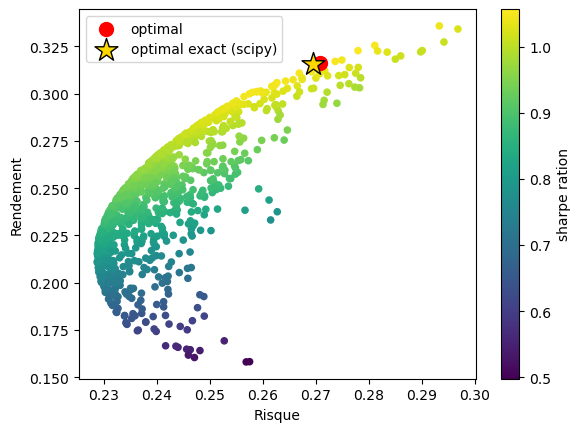

In [61]:
import yfinance as yf
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize 
D=yf.download(['AAPL','MSFT','GOOGL'],period='4y')['Close']
Rd=D.pct_change().dropna()
mu=Rd.mean().values*252
matrix=Rd.cov().values*252
rf = 0.03  
rendements, risque, poids, sharpe = [], [], [], []
for _ in range (1000):
    w=np.random.random(3)
    w=w/w.sum()
    rd=w@mu
    var=w@matrix@w
    ris=np.sqrt(var)# variance → ×temps (linéaire). Volatilité → ×√temps. Ne jamais annualiser une volatilité en la multipliant par 252.
    rendements.append(rd)
    risque.append(ris)
    poids.append(w)
rendements = np.array(rendements)
risque    = np.array(risque)
poids      = np.array(poids)
sharpe =(rendements-rf)/risque
sharpe_max=np.argmax(sharpe)

def neg_sharpe(w):#ce que fait cette fonction; donne-moi 3 poids, je te rends le −Sharpe de ce portefeuille » (un seul nombre) 
    rd  = w @ mu
    ris = np.sqrt(w @ matrix @ w)
    return -(rd - rf) / ris #raison du '-'minimize ne sait faire qu'une seule chose — trouver le MINIMUM (le point le plus bas, le fond du creux). Il ne sait pas chercher un maximum.
contraintes = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1} #lambda = une mini-fonction écrite en une ligne, la fonction qu'on force à 0 / 'eq' (égalité) : la fonction devra valoir 0
bornes = tuple((0, 1) for _ in range(3))  #bornes = ((0, 1), (0, 1), (0, 1)) resultat au lieu de l ecrire a la main pour chaque actif faut ecrire (0, 1)
w0 = np.array([1/3, 1/3, 1/3])  #Le point de départ
resultat = minimize(neg_sharpe, w0, method='SLSQP',bounds=bornes, constraints=contraintes)

w_opt = resultat.x #= ouvrir le compartiment « x », c'est-à-dire la solution (les poids optimaux)
rd_opt = w_opt @ mu
ris_opt = np.sqrt(w_opt @ matrix @ w_opt)
sharpe_opt = (rd_opt - rf) / ris_opt

print("=== Portefeuille optimal (scipy) ===")
print("Poids :", w_opt.round(3))
print(f"Rendement : {rd_opt:.2%} | Risque : {ris_opt:.2%} | Sharpe : {sharpe_opt:.2f}")
print(f"Rendement : {rendements[sharpe_max]:.2%} | Risque : {risque[sharpe_max]:.2%} | Sharpe : {sharpe[sharpe_max]:.2f}")

plt.scatter(risque,rendements,c=sharpe,cmap="viridis",s=20)
plt.colorbar(label='sharpe ration')
plt.scatter(risque[sharpe_max],rendements[sharpe_max],c='red',s=100,label='optimal')

plt.scatter(ris_opt, rd_opt, c='gold', s=300, marker='*', edgecolors='black', label='optimal exact (scipy)')

plt.xlabel('Risque')
plt.ylabel('Rendement')
plt.legend()
plt.show()
#print(f'le rendement annuel de l action est de {mu_ap*100:.2f}%')
#print(f'le rendement annuel de l action est de {mu_m*100:.2f}%')
#print(f'le rendement annuel de l action est de {mu_g*100:.2f}%')